# Exploratory Data Analysis (EDA)

Before building any model, our job is to understand our data, so we can understand our case. Every chart, every fix, every check has a specific question it's answering.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# we want clean plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print("All libraries loaded")

All libraries loaded


In [30]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [31]:
df.shape

(7043, 21)

In [32]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Observation

In [33]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Missing Data

In [34]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Basic Statistics

In [35]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Convertion

From the Dataset inspection we found that `TotalCharges` where stored as `object` instead of `numeric` value, so the next step is to convert its data type.

In [36]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

print(f"NaN in TotalCharges: {df['TotalCharges'].isnull().sum()}")

NaN in TotalCharges: 11


Since we have 11 missing values in our converted column, and we are talking about total charges, which means the spendings of a customer over their lifetime with the company, we need to fill it with 0, otherwise we will have incomplete information. 

__Why fill with 0 instead of the mean or dropping the rows?__

Because when we inspected the data, those new 11 missing rows with blank `TotalCharges` all have `tenure = 0`. That probably means that they are new customers who just signed up and haven't been billed yet. Their total charges genuinely are `0`, it's not missing data, it's correct data stored badly. 

Filling with 0 is the honest answer, while filling with the mean (≈$2,000) would be a lie that corrupts our model.

In [37]:
df['TotalCharges'].fillna(0, inplace=True)

print("TotalCharges fixed")

TotalCharges fixed


C:\Users\kwnst\AppData\Local\Temp\ipykernel_3612\1600997362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


## Data Visualization

####  Churn Distribution Chart

This is our target variable that we want to predict, so before looking to anything else we have to check if the porportion of churn and non-churn is balanced or imbalanced.

Because if 99% of customers don't churn and 1% do, a model that only predicts "No" gets 99% accuracy while being completely useless.

The first thing we need to do is to understand the split of the data before we choose the model and our evaluation metric.

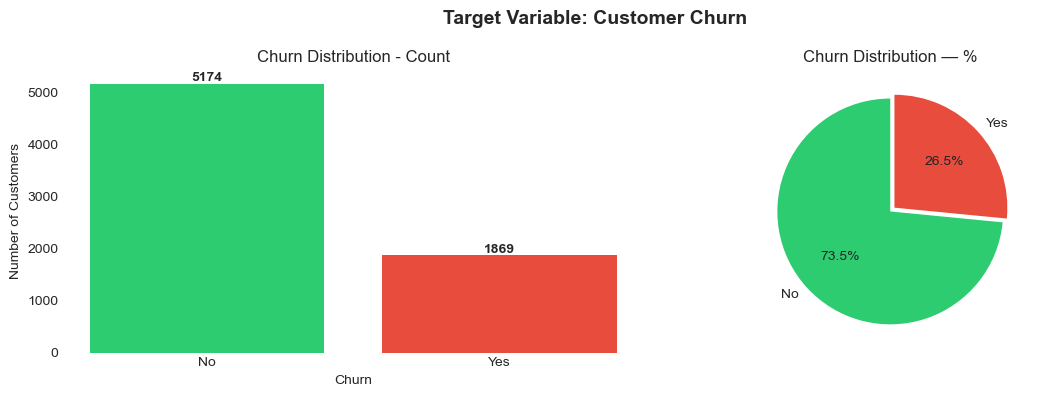


Churn rate: 26.5%


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Count Plot
churn_counts = df['Churn'].value_counts()

axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution - Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(False) 

for spine in axes[0].spines.values():
    spine.set_visible(False)

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# percentage pie
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Distribution — %')
axes[1].grid(False)

for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChurn rate: {(df['Churn']=='Yes').mean()*100:.1f}%")

__Results__

We found out that the Churn Rate is only 26.5% with 1869 as "Yes" and the other 73.5% with 5174 as "No", which means that our dataset is moderately imbalanced, but not that bad. We are going to handle that in the `Data Preprocessing` part later.

#### Histogram Chart - Numerical features vs churn

We are testing here three hypothesis, if actually churners and non-churners look different on these numbers. So we are going to check `tenure`, `MonthlyCharges` and `TotalCharges` hypothesis.

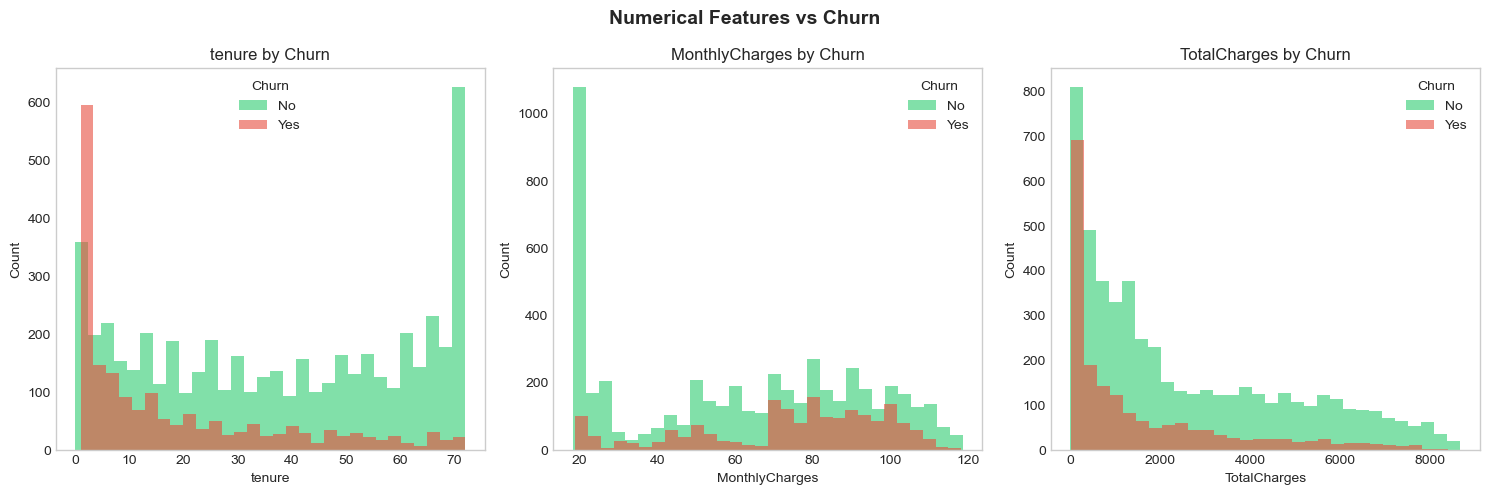

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = {'No': '#2ecc71', 'Yes': '#e74c3c'}

for ax, col in zip(axes, num_cols):
    for churn_val, color in colors.items():
        subset = df[df['Churn'] == churn_val][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=churn_val)
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(title='Churn')
    ax.grid(False)

plt.suptitle('Numerical Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

__Hypothesis Results__

- `tenure vs Churn`: Our hypothesis here is to see if customers who churn leave early. According to our chart, where red bars (churn=Yes) are concetrated on the left with the higher scale and decrising on the right, reveal that our hypothesis of customers who churn are actually leaving early. While those who not-churn stay at the company more, by looking to the green bars that spread further right.

- `MonthlyCharges vs Churn`: Our second hypothesis is that expensive plans probably cause churn. As we see in our second histogram chart. Since the red bars (churn = Yes) are slightly skewed right, meaning that there is an important possibilty that expensive plans are actually causing churns. However, that possibility is too small, instead the high green bar (no-churn), which shows higher patterns in comparison to the churn bars.

- `TotalCharges vs Churn`: In the third hypothesis we are checking if the amount of charges are causing churns, for example high charges --> lead to churn, while low charges --> lead to non-churn. According to our data exploration in the third histogram we observe that both churn and non-churn bars are left skewed, meaning that the patterns of both classes are not influenced from the TotalCharges as we believed, but we observe like in tenure that the people who churn are the ones that leave early.

So we consider the `TotalCharges` feature as not that important for our later model training.

#### Bar Chart - Categorical features vs churn

For categorical features Bar charts are the best way to illustrate the (%) rate between them and churn, because in this part we are not counting by raw, but we plot by churn rate (%).

For instance, if 5000 customers have DSL and 2000 have Fiber, raw count chart would make DSL look like the churn problem. However, if 15% of DSL customers churn vs 40% of Fiber customers, Fiber is the actual bigger risk. Percentage is very crucial in categorical features because normalizes for group size so we are comparing same analogy (e.g apples to apples).

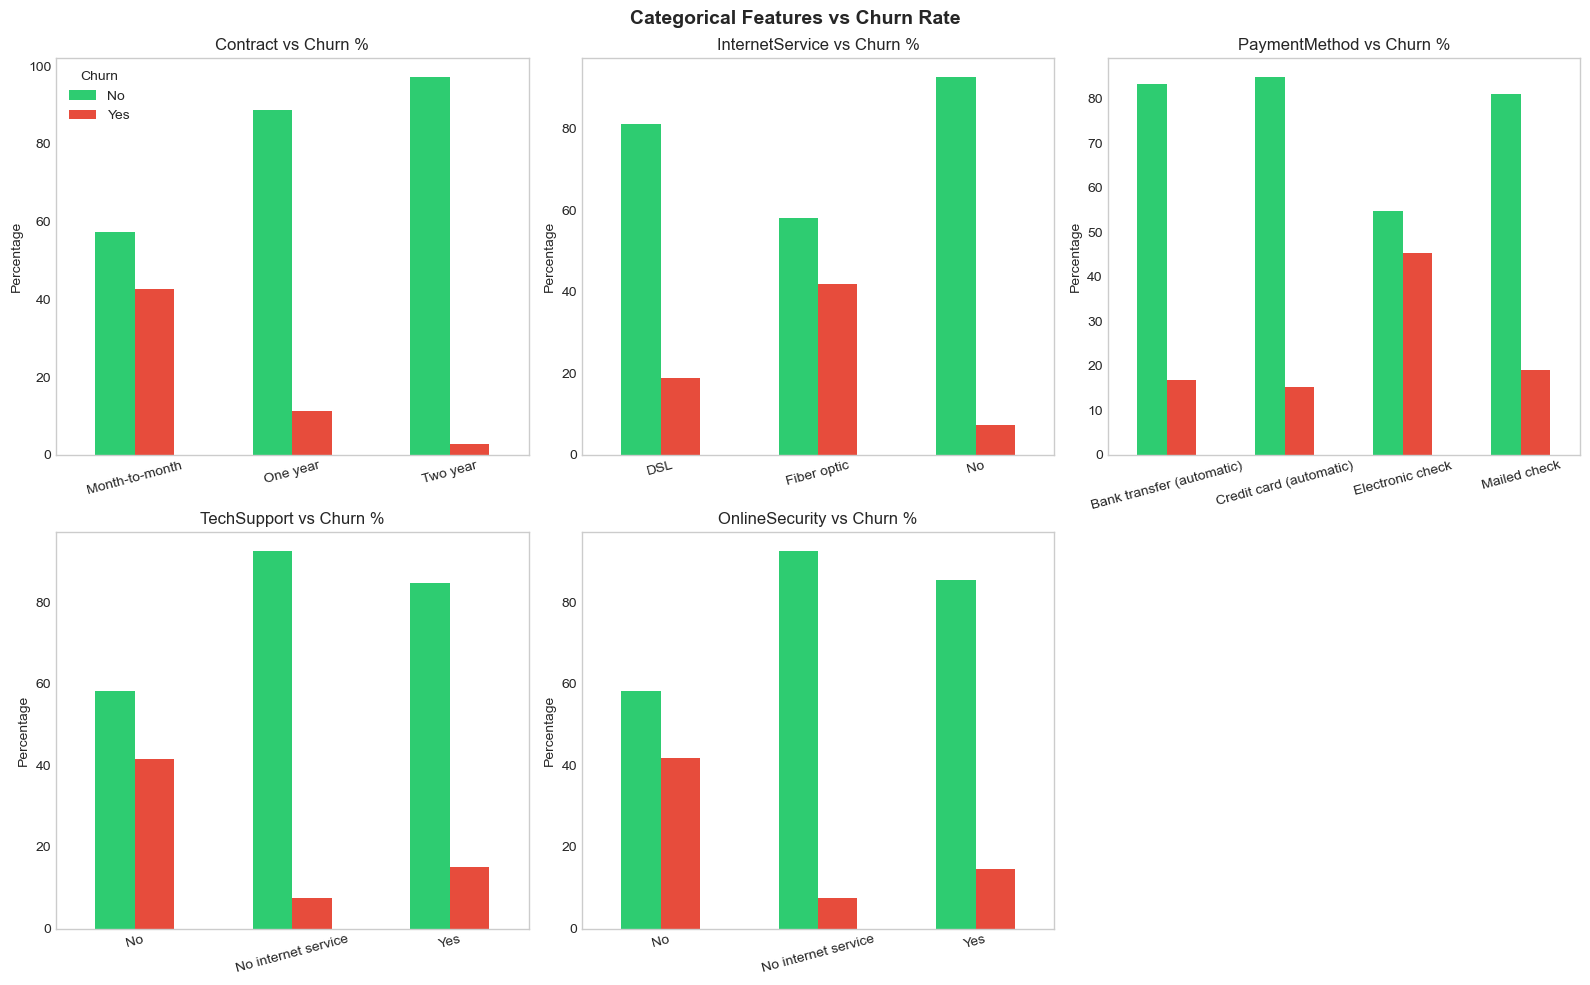

In [40]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()


for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            rot=15, legend=(i == 0))
    axes[i].set_title(f'{col} vs Churn %')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xlabel('')
    axes[i].grid(False)


axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

__Results__

- `Contract`: month-to-month customers as we see in our first bar chart, are easiest to leave, since they haven't lock-in into the company, instead of one-year or two-year contracts of staying in the same company.

- `InternetService`: We know that Fiber optic is more expensive and has more competition, so as it is obvious people seem to churn much more in comparison to DSL services.

- `PaymentMethod`: In the third bar chart about the payment method, we see that Electronic Check is a risky feature for people who churn. Since eletronic check is not autopay, meaning less commitment with the company, people will churn easier than the other payment methods.

- `TechSupport`: Customers who receive tech support for the company seem to not-churn that fast, because it is an important feature for possible damages on internet or missed connections.

- `OnlineSecurity`: Similarly, customers who receive online security are the ones that are not churning that fast or at least are not risking to churn, because having your devices protected or you internet and network is very crucial for keeping your devices and pesonal information safe.


#### Correlation Heatmap

With the heatmap correlation, we want to observe possible correlations between our features that the previous charts might missed, and see if are any of my input features talking about the same thing.

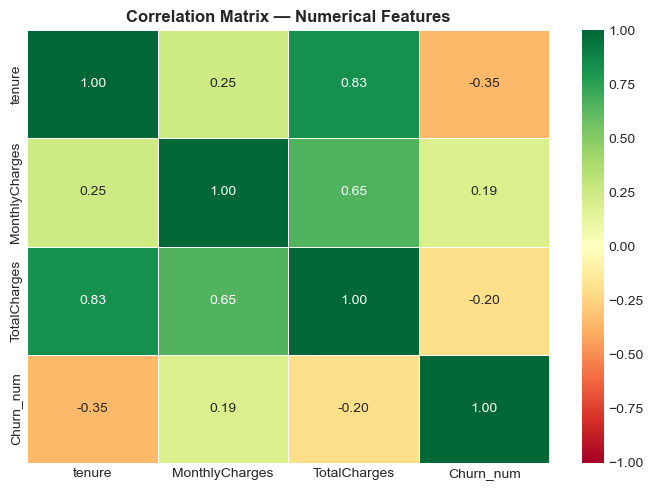

In [41]:
# Encode churn as 0/1 for correlation
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

# Only numeric columns
num_df = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']]

plt.figure(figsize=(7, 5))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

__Results__

- `tenure-TotalCharges`: those two features show a very high correlation (0.83), meaning that the longer a customer has stayed in the company, the more total charges they will have paid.

__CONCLUTION__

Every EDA step follows the same structure, we ask a question, pick the right tool for that question and interpret what we see. After all those steps we decide what to implement next.

Every chart illustration is helping us to decide for what will go in our model and what will be excluded, so we can decide how to build it.  

## Data Preprocessing

This is the part where we turn our raw data into something our machine learning model can actually consume. Models from their nature only understand numbers, and they are sensitive to scale and imbalance datasets. So in the next steps, every part will fix a specific problem.

__Drop customer ID column__

We need to drop our ID column first, before we do anything else. A model that learns and memorizing customer IDs, is not learning what it should. The model will fail on any new customer that have never seen before, because IDs are identifiers and not features.

In [42]:
df.drop('customerID', axis=1, inplace=True)

print(f"Colummns remaining: {df.shape[1]}")
print(df.columns.tolist())

Colummns remaining: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


__Encode Target variable__

As we said before every machine learning model needs numbers to learn best and faster, 'Yes' and 'No' are text. The next thing we have to do is encode our text into 1/0 mapping so the model has something to optimize against.

In [43]:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Churn value counts:')
print(df['Churn'].value_counts())
print(f"\n0 = Stay | 1 = Churn ")

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

0 = Stay | 1 = Churn 


__Separate binary yes/no columns__

We take these columns that contain only Yes/No values and transform the into 0/1 mapping, for cleaner and accurate results.

In [44]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']

binary_map = {'Yes': 1, 'No':0}

for col in binary_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].map(binary_map)

print("Binary columns encoded:")
print(df[binary_cols].head(3))

Binary columns encoded:
   Partner  Dependents  PhoneService  PaperlessBilling  SeniorCitizen
0        1           0             0                 1              0
1        0           0             1                 0              0
2        0           0             1                 1              0


__Transform Service Columns__

We take all the service columns having values like "No internet service" and tranform it into the same value and meaning that exist in the dataset, the value "No". We do that on all the columns that have same value context and make it more clear to the machine larning model, since it gives the same result and meaning the same thing. Keeping them separate creates a fake third category that adds noise without adding information.

In [45]:
service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'})
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Service columns encoded:")
print(df[service_cols].head(3))

Service columns encoded:
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  


__One-hot encode in left Categorical columns__

For making it easier to the model to learn, we transform the left columns into one-hot encoded values. We see that `Contract` has three values month-to-month, one year, two year. The best choice is to make them a 0/1 separate column for each category, so we can remove and avoid redundancy. So what we do is, drop one column per group, and if it is not one year and not two year, then it must be month-to-month.

In [46]:
cat_cols = ['InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=cat_cols, drop_first = True)

print(f"Shape after one-hot encoding: {df.shape}")
print("\nNew columns added:")
print([c for c in df.columns if any(cat in c for cat in cat_cols)])

Shape after one-hot encoding: (7043, 24)

New columns added:
['InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


__Checking if everything is numeric__

In [47]:
print("Any non-numeric columns remaining?")
print(df.select_dtypes(include='object').columns.tolist())

print(f"\nFinal shape: {df.shape}")
print("\nAll dtypes:")
print(df.dtypes.value_counts())

Any non-numeric columns remaining?
['gender']

Final shape: (7043, 24)

All dtypes:
int64      14
bool        7
float64     2
object      1
Name: count, dtype: int64


We see that the only remaining column that hasn't been preprocesed is `gender` so we have to encode it too, into 0/1 mapping.

In [48]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

print("gender encoded:", df['gender'].unique())

gender encoded: [0 1]


In [49]:
print("Any non-numeric columns remaining?")
print(df.select_dtypes(include='object').columns.tolist())

print(f"\nFinal shape: {df.shape}")
print("\nAll dtypes:")
print(df.dtypes.value_counts())

Any non-numeric columns remaining?
[]

Final shape: (7043, 24)

All dtypes:
int64      15
bool        7
float64     2
Name: count, dtype: int64


Now all the columns are preprocessed and ready.

__Split features and target__

In [50]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

Features (X): (7043, 23)
Target  (y): (7043,)

Feature columns (23):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


__Train/test split__

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify=y)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

Training set:  5,634 rows
Test set:      1,409 rows

Churn rate in train: 26.5%
Churn rate in test:  26.5%


__Scale numerical features__

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

print("Scaling applied ✓")
print(f"\ntenure mean after scaling: {X_train['tenure'].mean():.4f}  (should be ~0)")
print(f"tenure std after scaling:  {X_train['tenure'].std():.4f}   (should be ~1)")

Scaling applied ✓

tenure mean after scaling: -0.0000  (should be ~0)
tenure std after scaling:  1.0001   (should be ~1)


__Handle class imbalance__

In [53]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Churn=0: {(y_train==0).sum():,}  |  Churn=1: {(y_train==1).sum():,}")
print(f"After SMOTE  — Churn=0: {(y_train_balanced==0).sum():,}  |  Churn=1: {(y_train_balanced==1).sum():,}")
print(f"\nNew training size: {X_train_balanced.shape[0]:,} rows")

Before SMOTE — Churn=0: 4,139  |  Churn=1: 1,495
After SMOTE  — Churn=0: 4,139  |  Churn=1: 4,139

New training size: 8,278 rows


C:\Users\kwnst\anaconda3_1\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kwnst\anaconda3_1\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\kwnst\anaconda3_1\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kwnst\anaconda3_1\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

We use SMOTE (Synthetic Minority Oversampling Technique) instead of duplicating rows, because we don't want to copy the existing churner rows, but generate new synthetic customers by adding new ones according to the existing churners. This will give to our model more variety to learn from rather than memorizing the same 26% of rows over and over again.

## Model Building & Training

We will train three models, compare their results and then pick the more accurate one. The models will be `Logistic Regression`, `Random Forest` and `Gradient Boosting`.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

__Train all three models__

In [56]:
models = {
    'Logistic Regression': LogisticRegression(random_state = 42, max_iter = 1000),
    'Random Forest': RandomForestClassifier(random_state = 42, n_estimators = 100),
    'Gradient Boosting': GradientBoostingClassifier(random_state = 42, n_estimators = 100)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f" {name} trained")

 Logistic Regression trained
 Random Forest trained
 Gradient Boosting trained


__Evaluate all three__

In [57]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }

# comparison table
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
for name, r in results.items():
    print(f"{name:<25} {r['accuracy']:>10.4f} {r['roc_auc']:>10.4f}")

Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression           0.7445     0.8294
Random Forest                 0.7644     0.8247
Gradient Boosting             0.7381     0.8381


__ROC curves all three__

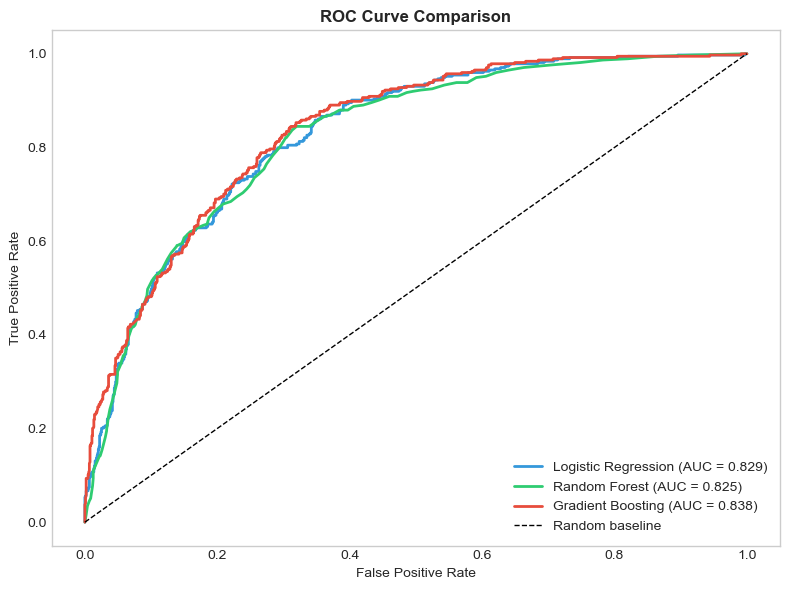

In [68]:
plt.figure(figsize=(8, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    auc = r['roc_auc']
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(False)
plt.savefig('../data/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

__Confusion matrix of the best performed model__

Best model: Gradient Boosting


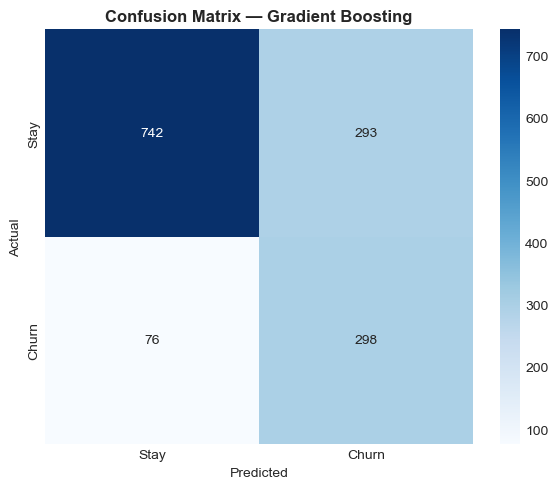


Detailed Report:
              precision    recall  f1-score   support

        Stay       0.91      0.72      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [59]:
best_name = max(results, key=lambda x: results[x]['roc_auc'])
best_pred = results[best_name]['y_pred']

print(f"Best model: {best_name}")

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, best_pred, target_names=['Stay', 'Churn']))

__Feature Importance of the Best model__

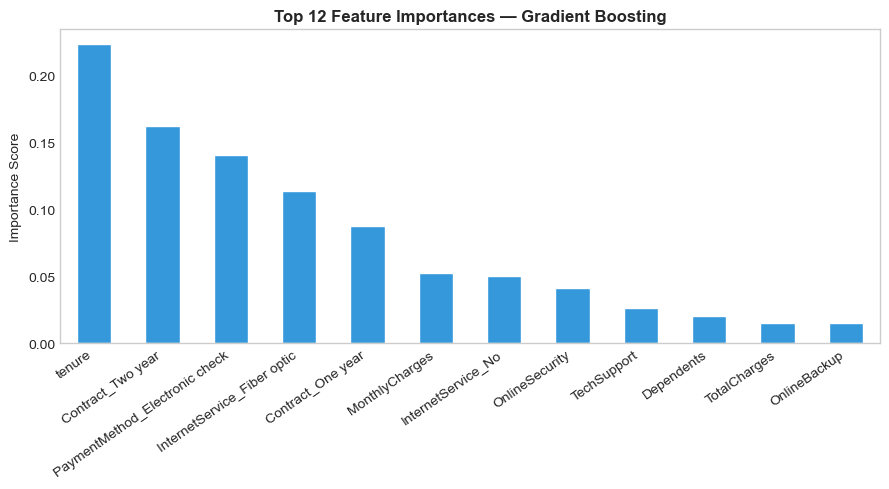

In [69]:
best_model = trained_models[best_name]

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False).head(12)

    plt.figure(figsize=(9, 5))
    importances.plot(kind='bar', color='#3498db', edgecolor='white')
    plt.title(f'Top 12 Feature Importances — {best_name}', fontweight='bold')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.grid(False)
    plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [61]:
joblib.dump(best_model, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print(f"✓ Model saved  → models/churn_model.pkl")
print(f"✓ Scaler saved → models/scaler.pkl")
print(f"\nBest model: {best_name}")
print(f"Saved successfully — ready for deployment")

✓ Model saved  → models/churn_model.pkl
✓ Scaler saved → models/scaler.pkl

Best model: Gradient Boosting
Saved successfully — ready for deployment


## Evaluation & Tuning

What we need to check now is how true our accuracy is. If our model says 80% accuracy, which sounds great, what it actually means. The two specific model evaluation results we need to check are recall and precision.

- __recall__ : of all customers who actually churned, how many did our model could catch.
- __precision__ : of all customers our model flagged as churn, how many actually did churn.

__Cross-validation__

In [62]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_model = trained_models[best_name]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model, X_train_balanced, y_train_balanced,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f"Model: {best_name}")
print(f"\nCross-validation ROC-AUC scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean:  {cv_scores.mean():.4f}")
print(f"Std:   {cv_scores.std():.4f}  ← lower is better (more stable)")

Model: Gradient Boosting

Cross-validation ROC-AUC scores:
  Fold 1: 0.8770
  Fold 2: 0.8766
  Fold 3: 0.8844
  Fold 4: 0.8824
  Fold 5: 0.8913

Mean:  0.8824
Std:   0.0054  ← lower is better (more stable)


Cross-validation trains and evaluates the model 5 times on different slices of data, so it can be more accurate and not lucky as a single train/test split. Since all folds give similar scores, our model is genuinely good. And by looking at our standard deviation, which is too low, are telling us that the model is stable.

__Threshold__

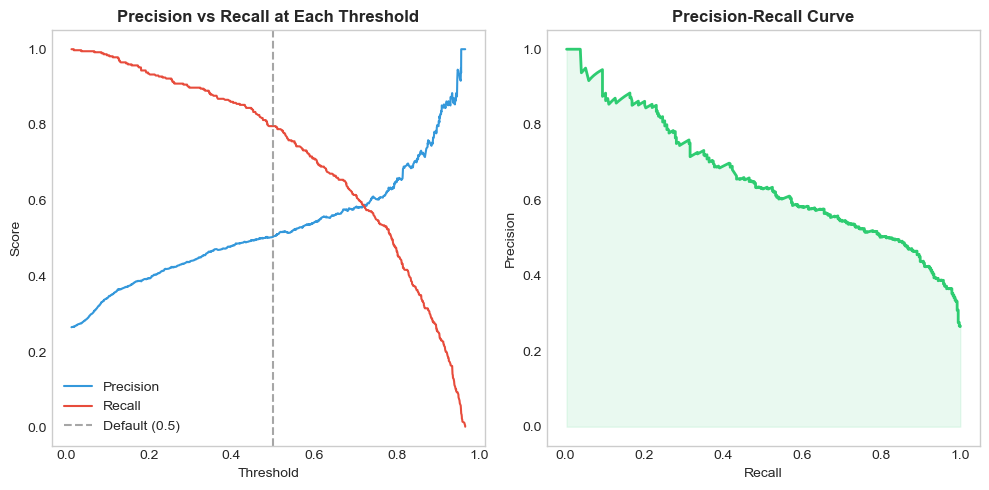

In [70]:
from sklearn.metrics import precision_recall_curve

y_prob = results[best_name]['y_prob']

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], '#3498db', label='Precision')
plt.plot(thresholds, recalls[:-1], '#e74c3c', label='Recall')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.grid(False)
plt.title('Precision vs Recall at Each Threshold', fontweight='bold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1], '#2ecc71', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(False)
plt.title('Precision-Recall Curve', fontweight='bold')
plt.fill_between(recalls[:-1], precisions[:-1], alpha=0.1, color='#2ecc71')

plt.tight_layout()
plt.savefig('../data/precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

__Optimal Threshold__

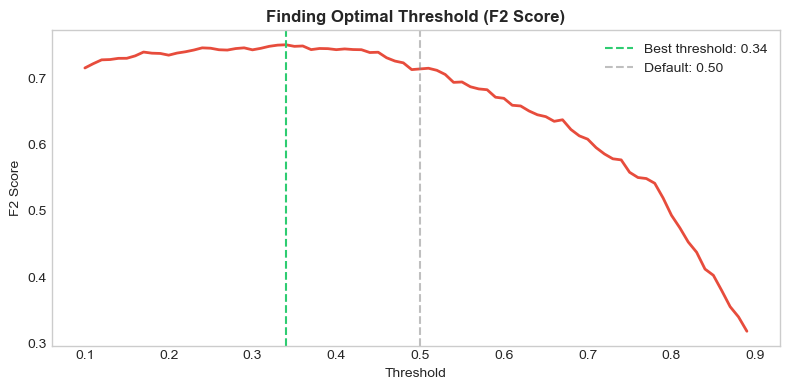

Optimal threshold: 0.34
Best F2 score:     0.7503


In [71]:
from sklearn.metrics import fbeta_score

f2_scores = []

threshold_range = np.arange(0.1, 0.9, 0.01)

for thresh in threshold_range:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f2 = fbeta_score(y_test, y_pred_thresh, beta=2)
    f2_scores.append(f2)

best_threshold = threshold_range[np.argmax(f2_scores)]
best_f2 = max(f2_scores)

plt.figure(figsize=(8, 4))
plt.plot(threshold_range, f2_scores, '#e74c3c', lw=2)
plt.axvline(x=best_threshold, color='#2ecc71', linestyle='--',
            label=f'Best threshold: {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default: 0.50')
plt.xlabel('Threshold')
plt.ylabel('F2 Score')
plt.title('Finding Optimal Threshold (F2 Score)', fontweight='bold')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Best F2 score:     {best_f2:.4f}")

__Default vs Optimized Threshold__

In [65]:
# Default threshold (0.5)
y_pred_default = (y_prob >= 0.50).astype(int)

# Optimized threshold
y_pred_optimized = (y_prob >= best_threshold).astype(int)

print("=" * 50)
print(f"DEFAULT THRESHOLD (0.50)")
print("=" * 50)
print(classification_report(y_test, y_pred_default,
                             target_names=['Stay', 'Churn']))

print("=" * 50)
print(f"OPTIMIZED THRESHOLD ({best_threshold:.2f})")
print("=" * 50)
print(classification_report(y_test, y_pred_optimized,
                             target_names=['Stay', 'Churn']))

DEFAULT THRESHOLD (0.50)
              precision    recall  f1-score   support

        Stay       0.91      0.72      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

OPTIMIZED THRESHOLD (0.34)
              precision    recall  f1-score   support

        Stay       0.94      0.62      0.75      1035
       Churn       0.46      0.89      0.61       374

    accuracy                           0.69      1409
   macro avg       0.70      0.76      0.68      1409
weighted avg       0.81      0.69      0.71      1409



__Confusion Matrix - Default vs Optimal Threshold__

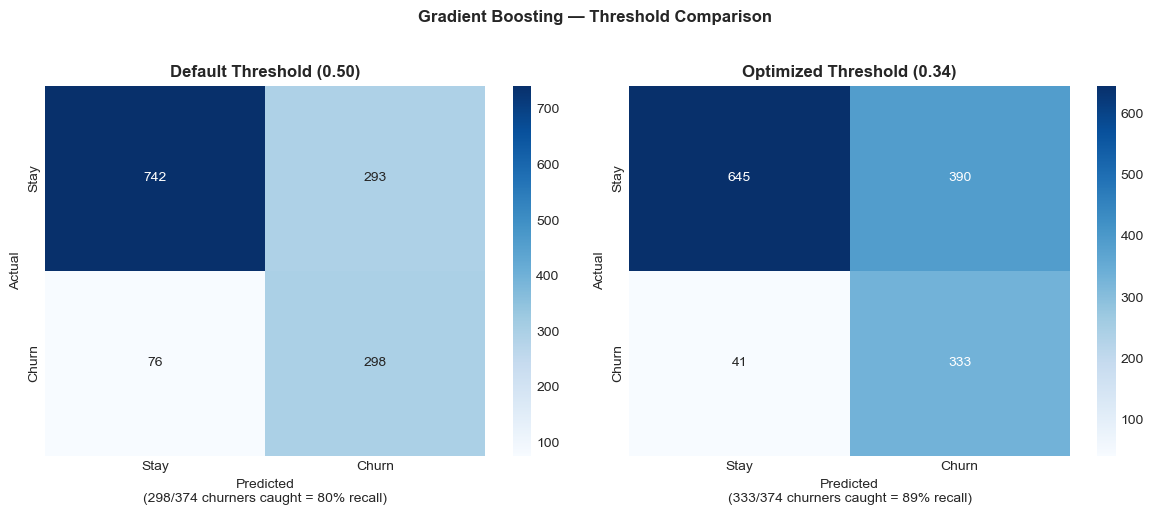

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_optimized],
    [f'Default Threshold (0.50)', f'Optimized Threshold ({best_threshold:.2f})']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stay', 'Churn'],
                yticklabels=['Stay', 'Churn'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

    # Annotate what each quadrant means
    total_churners = cm[1].sum()
    caught = cm[1][1]
    ax.set_xlabel(f'Predicted\n({caught}/{total_churners} churners caught = {caught/total_churners*100:.0f}% recall)')

plt.suptitle(f'{best_name} — Threshold Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Dropping the default threshold from 0.50 to 0.34, saved 35 extra customers from churn. In a real telecom company where a customer is worth ~ `$1200/year`, that is `$42000` in annual revenue recovered per 1409 customers scored.

In [67]:
import json

model_metadata = {
    'model_name': best_name,
    'optimal_threshold': float(best_threshold),
    'roc_auc': float(results[best_name]['roc_auc']),
    'feature_columns': list(X.columns)
}

with open('../models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✓ Metadata saved → models/model_metadata.json")
print(f"\nContents:")
print(json.dumps(model_metadata, indent=2))

✓ Metadata saved → models/model_metadata.json

Contents:
{
  "model_name": "Gradient Boosting",
  "optimal_threshold": 0.33999999999999986,
  "roc_auc": 0.8380634994445735,
  "feature_columns": [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "MonthlyCharges",
    "TotalCharges",
    "InternetService_Fiber optic",
    "InternetService_No",
    "Contract_One year",
    "Contract_Two year",
    "PaymentMethod_Credit card (automatic)",
    "PaymentMethod_Electronic check",
    "PaymentMethod_Mailed check"
  ]
}
